<a href="https://colab.research.google.com/github/ddezouza/Data201_DanielaMelo/blob/main/Melo_Project1_Week8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1 - Exploring Race Data from the 2024 Monaco Formula 1 Grand Prix



#### Daniela Melo
#### March 31st, 2026

### Introduction

For Project 1, I chose to explore a topic that is of interest to me on a personal level. As both my sister and my father are big Formula 1 (F1) fans, and there is a significant amount of data involved in F1 as a sport, it seemed a suitable topic for a data analysis project.

I searched online for curated F1 datasets that I might use for this project and stumbled onto the fastf1 project and its associated python package. FastF1 is a python package intended for the analysis of F1 data. It combines data from multiple open sources and available APIs, such as the F1 Livetiming API and Ergast API. The data is compiled, corrected, and occasionally augmented with additional sources, and becomes available through python code calls once the fastf1 package is installed and imported for use.

For the purposes of this project, I chose to focus on a single race session from 2024. I selected the Monaco Grand Prix as it is one of the races with the highest number of laps and was therefore most likely to have over 1000 laps total when all drivers are taken into account, and the requirements for this project indicated the dataset size should have at least 1000 rows. I chose to look at lap times and tire type as my two key variables and therefore the total number of laps was a key consideration in choosing what race to extract from the fastf1 package.

####Data source:
Schafer, P. (3.8.1). FastF1: FastF1 is a python package for accessing and analyzing Formula 1 results, schedules, timing data and telemetry.
[GitHub](https://github.com/theOehrly/Fast-F1)
Retrieved March 28, 2026 from https://docs.fastf1.dev/index.html



## Preparatory Steps

### Sourcing the Data

In [3]:
#Installing python FastF1 package for Formula 1 data and analysis
!pip install fastf1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.8 MB/s eta 0:00:00


In [105]:
#Importing all other packages
import fastf1 as ff
import fastf1.plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import scipy
from sklearn.linear_model import LinearRegression


In [5]:
#Download race data - Race selected is the 2024 Monaco Grand Prix
session = ff.get_session(2024,"Monaco","R")
session.load()

req         WARNING 	DEFAULT CACHE ENABLED! (24.0 KB) /root/.cache/fastf1
core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.2]
INFO:fastf1.fastf1.core:Loading data for Monaco Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading 

In [6]:
#laps  information for all drivers contains the time and tire data I want to use
laps = session.laps.copy()

In [7]:
#Confirming Monaco Race fits dataset requirement (1000 rows and at least 4 variables)
print( "Dataset shape:", laps.shape)
print("Rows:", laps.shape[0])
print("Columns:",laps.shape[1])

Dataset shape: (1237, 31)
Rows: 1237
Columns: 31


In [8]:
#Confirming presence of at least 1 numerical and 1 categorical variable
laps.info()

<class 'fastf1.core.Laps'>
RangeIndex: 1237 entries, 0 to 1236
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype          
---  ------              --------------  -----          
 0   Time                1237 non-null   timedelta64[ns]
 1   Driver              1237 non-null   object         
 2   DriverNumber        1237 non-null   object         
 3   LapTime             1226 non-null   timedelta64[ns]
 4   LapNumber           1237 non-null   float64        
 5   Stint               1237 non-null   float64        
 6   PitOutTime          23 non-null     timedelta64[ns]
 7   PitInTime           23 non-null     timedelta64[ns]
 8   Sector1Time         1217 non-null   timedelta64[ns]
 9   Sector2Time         1233 non-null   timedelta64[ns]
 10  Sector3Time         1213 non-null   timedelta64[ns]
 11  Sector1SessionTime  1216 non-null   timedelta64[ns]
 12  Sector2SessionTime  1233 non-null   timedelta64[ns]
 13  Sector3SessionTime  1213 non-null   timedelt

In [9]:
#Need to convert timedelta into seconds to treat it as numeric
df= (
    laps
    .dropna(subset="LapTime")#removing NANs from my numerical data
    .query("PitOutTime.isnull() and PitInTime.isnull()")#removing laps where there was a pitstop because I don't want laps where the cars stopped.
    .assign(lap_time_s=lambda d: d["LapTime"].dt.total_seconds())
)

In [10]:
#Checking my new df
df.info()

<class 'fastf1.core.Laps'>
Index: 1187 entries, 2 to 1232
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype          
---  ------              --------------  -----          
 0   Time                1187 non-null   timedelta64[ns]
 1   Driver              1187 non-null   object         
 2   DriverNumber        1187 non-null   object         
 3   LapTime             1187 non-null   timedelta64[ns]
 4   LapNumber           1187 non-null   float64        
 5   Stint               1187 non-null   float64        
 6   PitOutTime          0 non-null      timedelta64[ns]
 7   PitInTime           0 non-null      timedelta64[ns]
 8   Sector1Time         1187 non-null   timedelta64[ns]
 9   Sector2Time         1187 non-null   timedelta64[ns]
 10  Sector3Time         1187 non-null   timedelta64[ns]
 11  Sector1SessionTime  1186 non-null   timedelta64[ns]
 12  Sector2SessionTime  1187 non-null   timedelta64[ns]
 13  Sector3SessionTime  1187 non-null   timedelta64[n

In [12]:
#Isolating the columns I want to work with and making sure I have no missing values (Note dfs use british spelling for tire)
df_clean=df[["Driver","Compound","TyreLife","LapNumber","lap_time_s"]].dropna()

## Dataset Structure

In [13]:
df_clean.info()

<class 'fastf1.core.Laps'>
Index: 1187 entries, 2 to 1232
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Driver      1187 non-null   object 
 1   Compound    1187 non-null   object 
 2   TyreLife    1187 non-null   float64
 3   LapNumber   1187 non-null   float64
 4   lap_time_s  1187 non-null   float64
dtypes: float64(3), object(2)
memory usage: 55.6+ KB


In [43]:
#Describing variables in a table:
pd.DataFrame({
    "Variable Name": ["Driver","Compound","TyreLife","LapNumber","lap_time_s"],
    "Definition": ["Driver's name.","Type of tire used.","Age of tire in number of laps.","Lap number in Monaco race.","Lap time in seconds."],
    "Variable Type": ["Categorical","Categorical","Numeric","Numeric","Numeric"]
})

,Variable Name,Definition,Variable Type
0,Driver,Driver's name.,Categorical
1,Compound,Type of tire used.,Categorical
2,TyreLife,Age of tire in number of laps.,Numeric
3,LapNumber,Lap number in Monaco race.,Numeric
4,lap_time_s,Lap time in seconds.,Numeric


In [22]:
#Extracting my isolated dataset for future reference - this is the csv I added to my Github
df_clean.to_csv("Clean F1 Data.csv",index=False)

## Analyses

### Quantitative Variable (Descriptive)

- How many seconds do drivers need to complete a lap in the Monaco Grand Prix circuit?

My research question refers to the general tendency for lap times during the 2024 Monaco Grand Prix. In order to properly calculate the measures of central tendency and spread for my dataset so I could properly answer the question I had to transform the timedelta variable from my original dataset into a numerical variable (essentially converting lap time so I had a total number of seconds that I could utilize as the value for each lap). I also made sure I dropped NAs as I compiled my clean dataframe. Details of this process are included in the code of the above section.

In [34]:
#Exploring Numerical variable lap_time_s
#Summary Statistics
print(f'Mean Lap Time (s):{np.mean(df_clean['lap_time_s']):.6}')
print(f'Median Lap Time (s):{np.median(df_clean['lap_time_s']):.6}')
print(f'Max Lap Time (s):{np.max(df_clean['lap_time_s']):.3}')
print(f'Min Lap Time (s):{np.min(df_clean['lap_time_s']):.3}')
print(f'Standard Deviation of Lap Time (s):{np.std(df_clean['lap_time_s']):.3}')
print(f'Range for Lap Time (s):{np.max(df_clean['lap_time_s'])-np.min(df_clean['lap_time_s']):.3}')

Mean Lap Time (s):79.5162
Median Lap Time (s):79.484
Max Lap Time (s):90.4
Min Lap Time (s):74.2
Standard Deviation of Lap Time (s):2.19
Range for Lap Time (s):16.2


Measures of central tendency and spread are as described in the above code. Median and Mean lap times were close, which would indicate the data for lap times in seconds should be relatively symmetrical, though when put to a histogram the lap time (s)  distribution seems to have some outlying values that may cause a right skew.

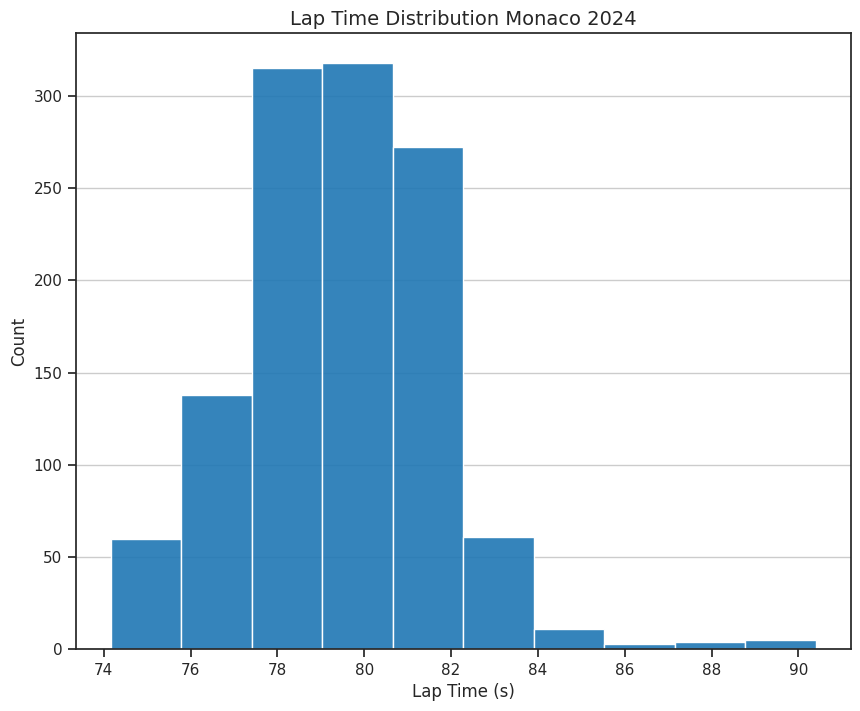

In [37]:
#Summarizing data structure and features
plt.figure(figsize=(10,8))
sns.set_theme(style='ticks')
sns.set_palette('tab20')
sns.histplot(data=df_clean,x='lap_time_s',kde=False, alpha=.90, bins=10)
plt.xlabel('Lap Time (s)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title("Lap Time (s) Distribution Monaco 2024", fontsize=14)
plt.grid(True, axis='y',zorder=0)
plt.show()

In [40]:
#To verify skewness:
print(f'Skewness for Lap Time (s) Distribution: {scipy.stats.skew(df_clean['lap_time_s']):.3}')

Skewness for Lap Time (s) Distribution: 0.546


The scipy skew measures the skewness of the distribution and confirms there is a slight right skew to the lap time data, though the bulk of it is relatively symmetrical and likely accounts for the close mean and median values.

### Categorical Variable (Descriptive)

- How do tire type/compounds differ from each other? Do lap times differ between tyre compounds?

For my categorical variable, I chose to explore the tire types used in F1 racing. There are 3 tire types: Hard, Medium, and Soft. Tire type is know to have significant impact in racing strategies as a whole, so I wanted to understand better the differences the compounds may create when it comes to lap times.

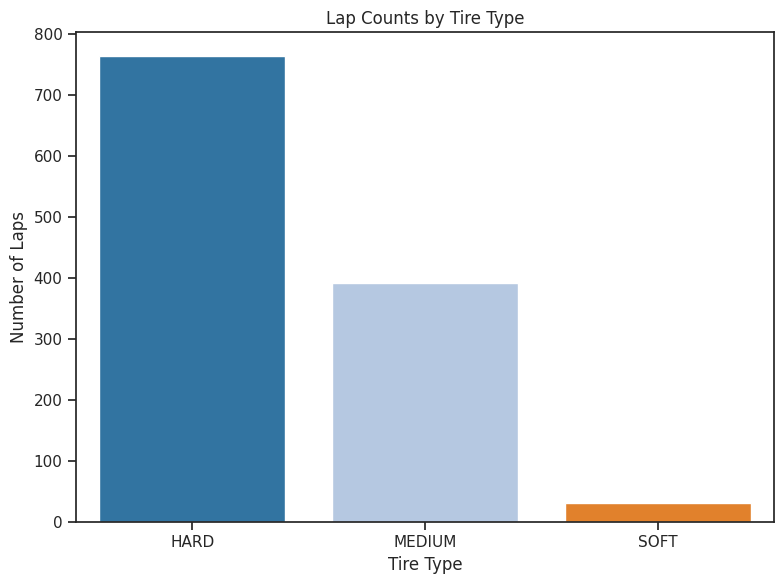

In [119]:
counts = (
    df_clean["Compound"]
    .value_counts()
    .reset_index()
)
counts.columns = ["Compound", "Count"]

plt.figure(figsize=(8, 6))
sns.barplot(data=counts,x="Compound",y="Count", hue="Compound")

plt.xlabel("Tire Type")
plt.ylabel("Number of Laps")
plt.title("Lap Counts by Tire Type")
plt.tight_layout()
plt.show()


Hard tires were the most used tire type in the Monaco Grand Prix, used for the greatest number of laps. Soft tires, on the other hand, were used the least, used for less than 100 laps.

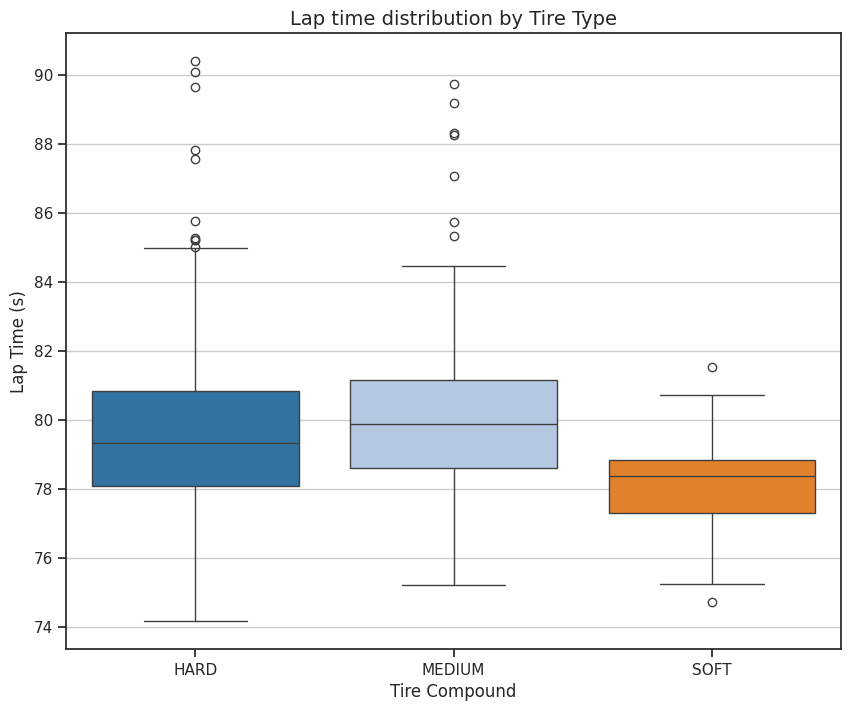

In [120]:
plt.figure(figsize=(10,8))
sns.set_theme(style='ticks')
sns.set_palette('tab20')
sns.boxplot(data=df_clean,x='Compound',y='lap_time_s', hue='Compound')
plt.xlabel('Tire Compound', fontsize=12)
plt.ylabel('Lap Time (s)', fontsize=12)
plt.title("Lap time distribution by Tire Type", fontsize=14)
plt.grid(axis='y')
plt.show()

When graphing the lap time distribution by compound using a box and whisker plot, it becomes clear that there are significant differences in lap time depending on the type of tire used. Soft tires have a lower median lap time than Hard or Medium tires, and also have a more limited range of lap times represented. Medium tires have the highest median lap time in seconds, while Hard tires showcase the greatest range in lap times.

This made me wonder whether Tire age differs significantly between tire compounds. Would a Hard compound tire be more long-lasting and be used for more laps, potentially explaining the larger range in lap times for that group?

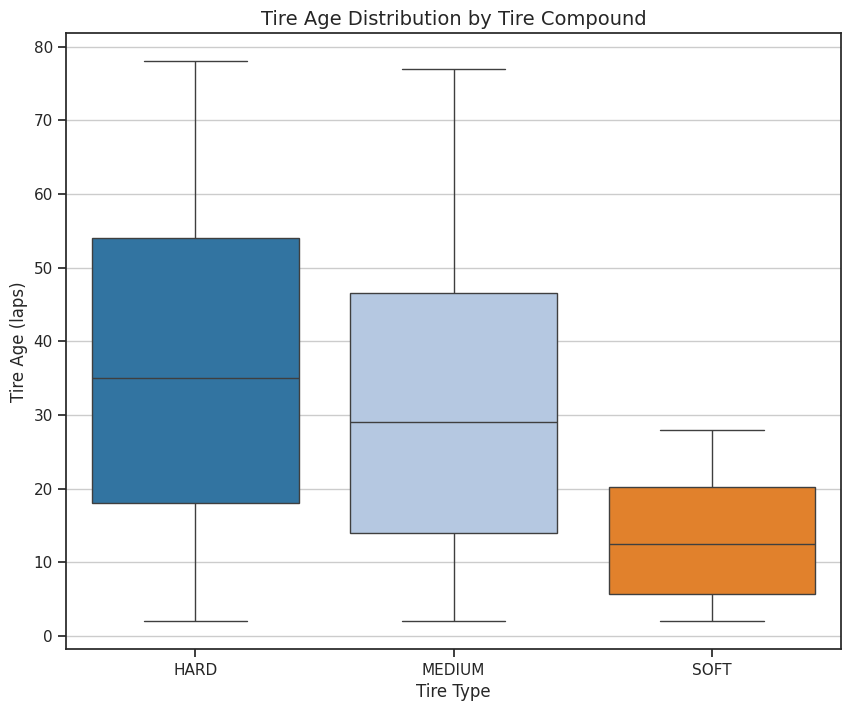

In [113]:
plt.figure(figsize=(10,8))
sns.set_theme(style='ticks')
sns.set_palette('tab20')
sns.boxplot(data=df_clean,x='Compound',y='TyreLife', hue='Compound')
plt.xlabel('Tire Type', fontsize=12)
plt.ylabel('Tire Age (laps)', fontsize=12)
plt.title("Tire Age Distribution by Tire Compound", fontsize=14)
plt.grid(axis='y')
plt.show()

I plotted Tire Age (laps) distributions by Tire type using a second box and whisker plot, and it is clear that the different tire types do have significantly different lifespans. Soft tires are much more short lived than Hard and Medium tires. Hard tires did have the highest median age measured, though the tire age range for medium and hard type tires was relatively similar.

### Relationship Between Variables (Exploratory)

Given I had reviewed how tire types differed when it comes to resulting lap times, and that they had significantly different life spans, I wanted to determine whether tire type and age would be good predictors of lap time in the Monaco Grand Prix. I expect older tires would be associated with higher lap times, and that soft tires, especially when new, would be associated with shorter lap times.

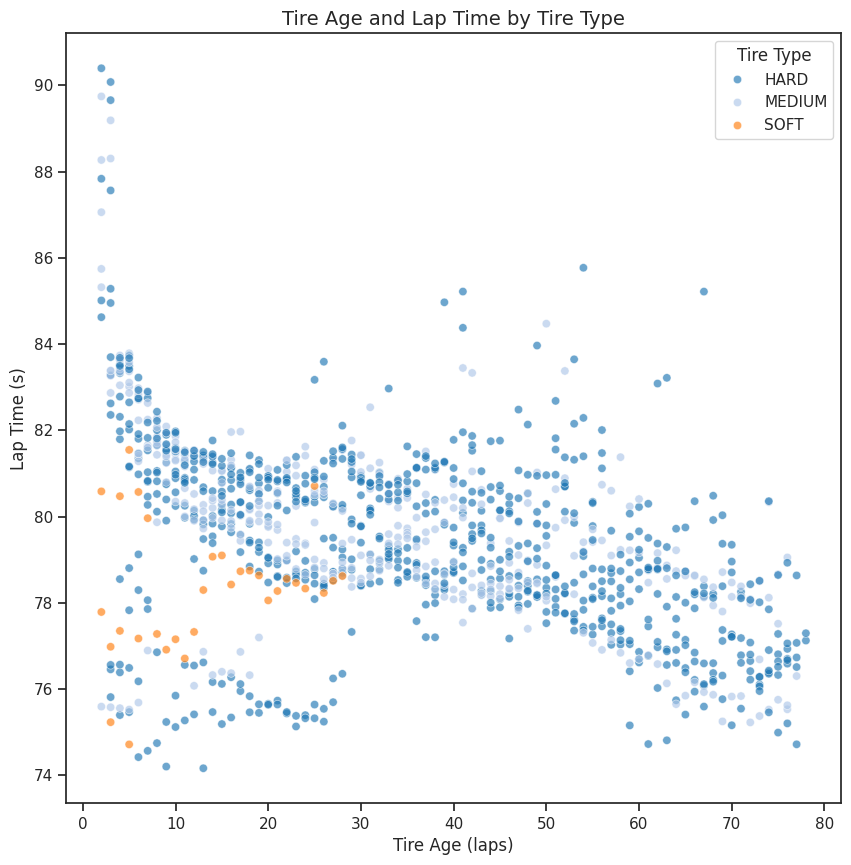

In [114]:
#Plotting Tire Life vs Lap Times (s)
sns.set_palette('tab20')
plt.figure(figsize=(10,10))
sns.scatterplot(data=df_clean, x='TyreLife', y='lap_time_s', hue='Compound', alpha=0.65)
plt.xlabel('Tire Age (laps)', fontsize=12)
plt.ylabel('Lap Time (s)', fontsize=12)
plt.title("Tire Age and Lap Time by Tire Type", fontsize=14)
plt.legend(title="Tire Type")
plt.show()

I decided to try and fit a linear regression model to see whether the relationship could be easily explained.

In [45]:
model = smf.ols('lap_time_s ~ TyreLife + C(Compound)', data=df_clean).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             lap_time_s   R-squared:                       0.245
Model:                            OLS   Adj. R-squared:                  0.243
Method:                 Least Squares   F-statistic:                     128.0
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           8.27e-72
Time:                        22:31:49   Log-Likelihood:                -2447.4
No. Observations:                1187   AIC:                             4903.
Df Residuals:                    1183   BIC:                             4923.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                81.1800      0.119    685.020      0.000      80.948      81.413
C(Compound)[T.MEDIUM]     0.3075      0.119      2.584      0.010       0.074       0.541
C(Compound)[T.SOFT]      -2.1884      0.349     -6.268      0.000      -2.873      -1.503
TyreLife                 -0.0499      0.003    -18.756      0.000      -0.055      -0.045
==============================================================================
Omnibus:                      101.152   Durbin-Watson:                   0.610
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              575.000
Skew:                           0.079   Prob(JB):                    1.38e-125
Kurtosis:                       6.406   Cond. No.                         256.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The model summary provides some very interesting results. While the p values are all lower than 0.05, indicating the significance of the variables included in the model in impacting lap time in the Monaco Grand Prix, the R squared value for the model is 0.245, indicating that less than 25% of the variation in lap time (s) can be explained by Tire age and Tire type. It'd be interesting to see what other variables could be added to the model to explain lap time and whether other models may be a better fit than a linear regression.

### Nonparametric Inference (median)

I used a 10% subset of my data to perform 5000 resamples for a bootstrap estimate of the median.

In [89]:
# Bootstrap where a random subset of 10% of the full dataset is used as the empirical population. (subset then bootstrap)

#Extract 10% of the data
lap_times_full=df_clean['lap_time_s'].to_numpy()
N=len(lap_times_full)

rng=np.random.default_rng()

subset_size=int(0.10*N)

subset=rng.choice(lap_times_full,size=subset_size,replace=False)#we're extracting a random subset of 10% of our existing data, so we're doing it without replacement.

In [75]:
#Bootstrapping the 10% subset

n_bootstrap = 5000

bootstrap_medians = []

for i in range(n_bootstrap):
    sample = np.random.choice(
        subset,
        size=len(subset),
        replace=True)
    bootstrap_medians.append(np.median(sample))

bootstrap_medians = np.array(bootstrap_medians)

In [76]:
bootstrap_median = np.median(bootstrap_medians)
lower, upper = np.percentile(bootstrap_medians, [2.5, 97.5])

print(f"Bootstrap median: {bootstrap_median:.3f} s")
print(f"95% CI: [{lower:.3f}, {upper:.3f}] s")

Bootstrap median: 79.786 s
95% CI: [79.029, 80.304] s


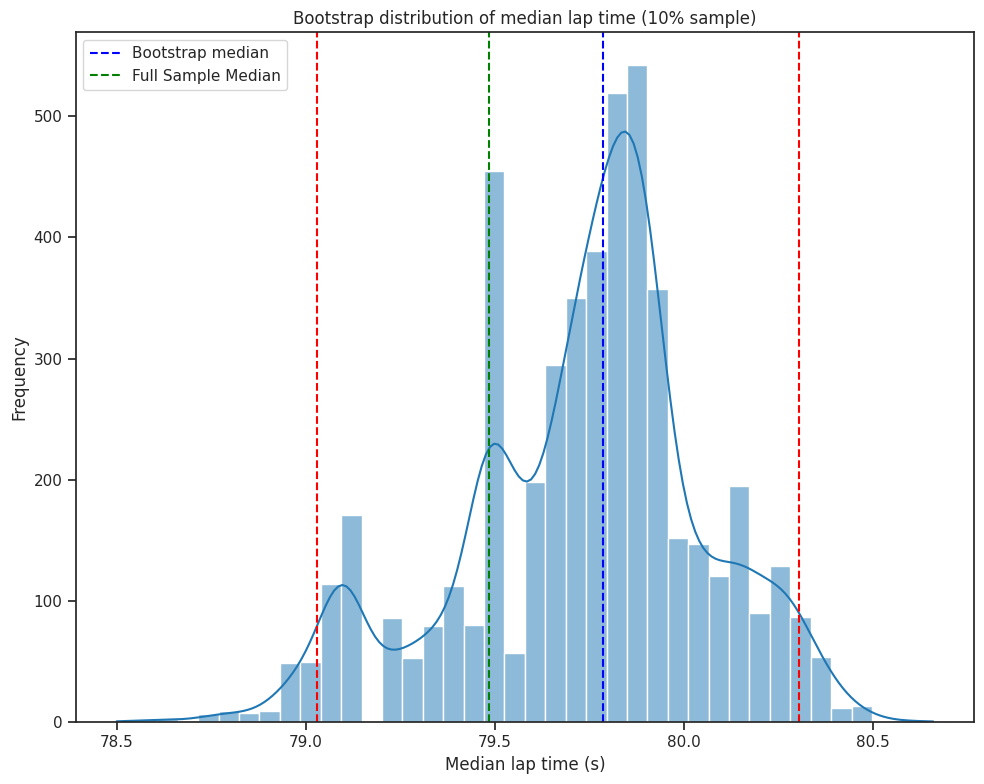

In [77]:
plt.figure(figsize=(10,8))
sns.histplot(bootstrap_medians, bins=40, kde=True)
plt.axvline(np.median(bootstrap_medians),color="blue",linestyle="--",label="Bootstrap median")
plt.axvline(np.median(df_clean['lap_time_s']),color='green',linestyle="--",label='Full Sample Median')
plt.axvline(x=lower, ymin=0, ymax=1, color='red', linestyle='--')
plt.axvline(x=upper, ymin=0, ymax=1, color='red', linestyle='--')
plt.xlabel("Median lap time (s)")
plt.ylabel("Frequency")
plt.title("Bootstrap distribution of median lap time (10% sample)")
plt.legend()
plt.tight_layout()
plt.show()

In [70]:
print(f"Bootstrap median: {bootstrap_median:.5f} s")
print(f"Full Sample Median:{np.median(df_clean['lap_time_s']):.5f} s")

Bootstrap median: 79.74500 s
Full Sample Median:79.48400 s


This approach uses only 10% of the original dataset as the empirical population. It provides an estimate for the median of the data based on the 10% subset that is resampled 5000 times. The bootstrapped median for the 10% subset (79.745 s) is relatively far away from the median lap time we calculated for the full sample (79.484 s).

## Conclusions / Recommendations



In the process of completing this project, I was able to define the following key findings:

1. The median time needeed to complete 1 lap in the 2024 Monaco Grand Prix was 74.48 seconds.
2. Median Lap time and tire lifespan can vary depending on the type of tire - soft tires have lowest lap times and don't last as long as hard and medium tires. Hard tires had the greatest lap time range of all tire types.
3. Tire type and age are significant factors affecting lap time, but only explained approximately 24% of the variation in lap time. It is possible that additional variables or an alternative model would be needed to further explain lap time variation.
4. A 10% subset of the sample can be effectively used to estimate the median within a 95% confidence interval, though of course it will have a greater measure of uncertainty than an estimate based on a larger sample.

For further analysis:

It would be interesting to try and use additional variables (such as car/engine manufacturer, track conditions, and weather) to try and further explain lap time. Alternatively, I think it may be helpful to try and further fine tune the laps used in analysis - I removed laps where pitstops occurred, but for future analysis it may be possible to remove laps completed under a safety car, yellow flag, or where an accident occurred.